<h1>Student Performance Indicator</h1>

<h3>Life Cycle of Machine Life cycle</h3>

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

<h4>1) Problem statement</h4>

- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

<h4>2) Data Collection</h4>

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

# Import the CSV data 

In [5]:
df = pd.read_csv("data/stud.csv")


Show Top 5 Records

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of dataset

In [7]:
df.shape

(1000, 8)

2.2 Dataset information

- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

# 3.1 Check Missing values

In [8]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the data set

# 3.2 Check Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

# 3.3 Check data types

There are no duplicates values in the data set

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# 3.4 Checking the number of unique values of each column

In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
df['race_ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

# 3.5 Check statistics of data set

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

# 3.7 Exploring Data

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [16]:
# Numerical columns
numeric_features = df.select_dtypes(exclude='object').columns

# Categorical columns
categorical_features = df.select_dtypes(include='object').columns

print("Numerical Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['math_score', 'reading_score', 'writing_score']
Categorical Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [17]:
df.dtypes

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

# 3.8 Adding columns for "Total Score" and "Average"

In [18]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [19]:
maths_full = df[df['math_score'] == 100]['average'].count()
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {maths_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [20]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


Insights

- From above values we get students have performed the worst in Maths
- Best performance is in reading section

# 4. Exploring Data ( Visualization )

4.1 Visualize average score distribution to make some conclusion.

- Histogram
- Kernel Distribution Function (KDE)

4.1.1 Histogram & KDE

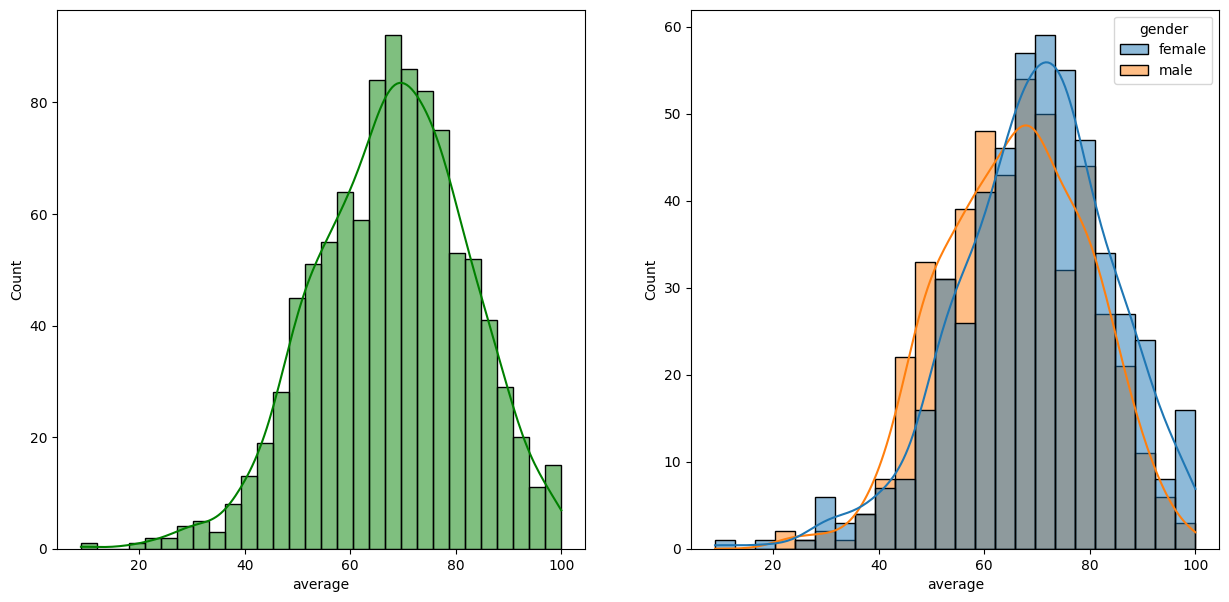

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(1, 2, 2)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

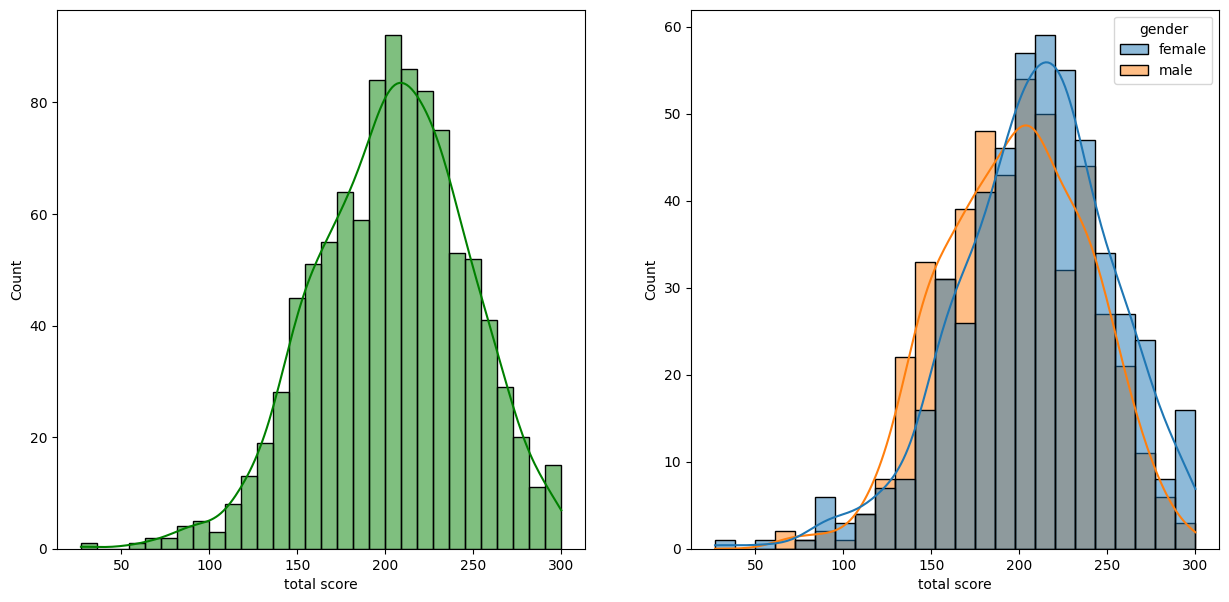

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(1, 2, 2)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

Insights

- Female students tend to perform well then male students.

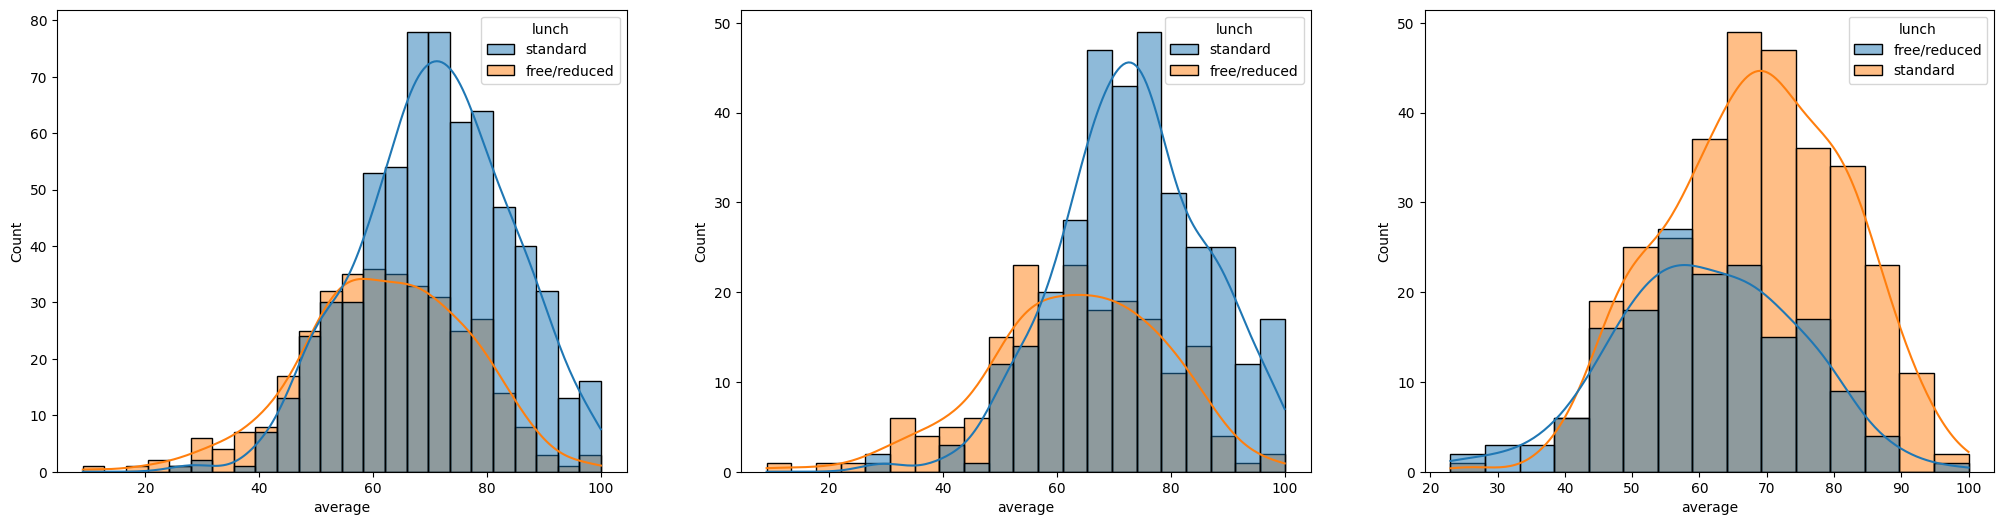

In [23]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

Insights

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

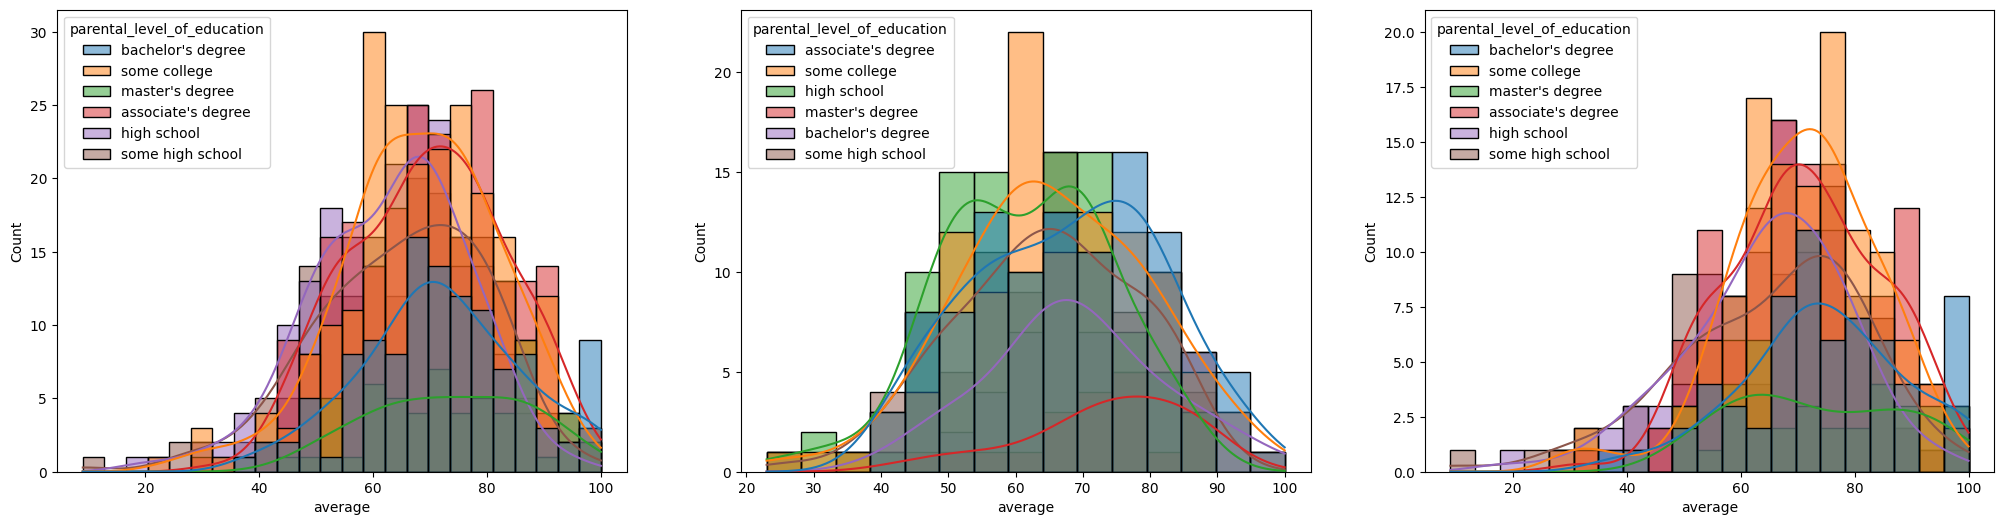

In [24]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(1,3,2)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(1,3,3)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

Insights

- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

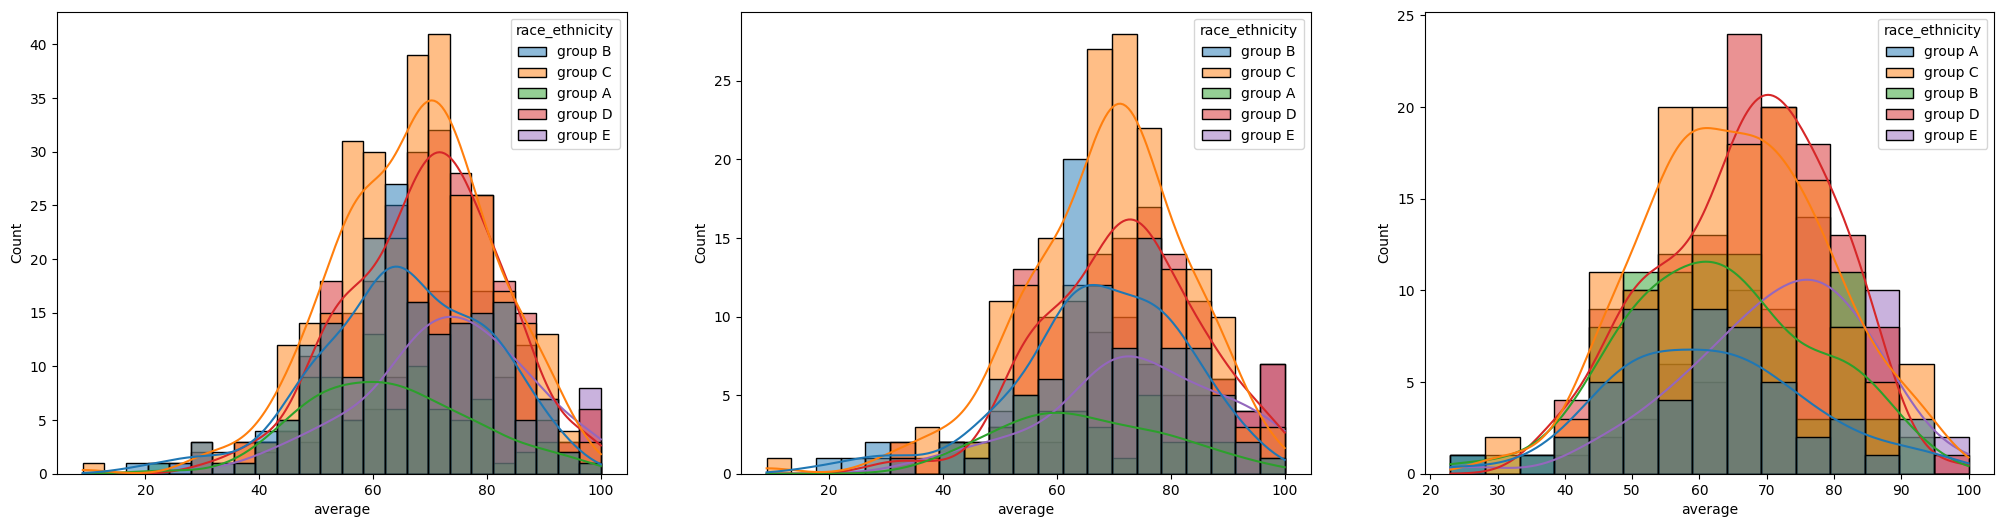

In [26]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,3,2)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,3,3)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

# 4.2 Maximumum score of students in all three subjects

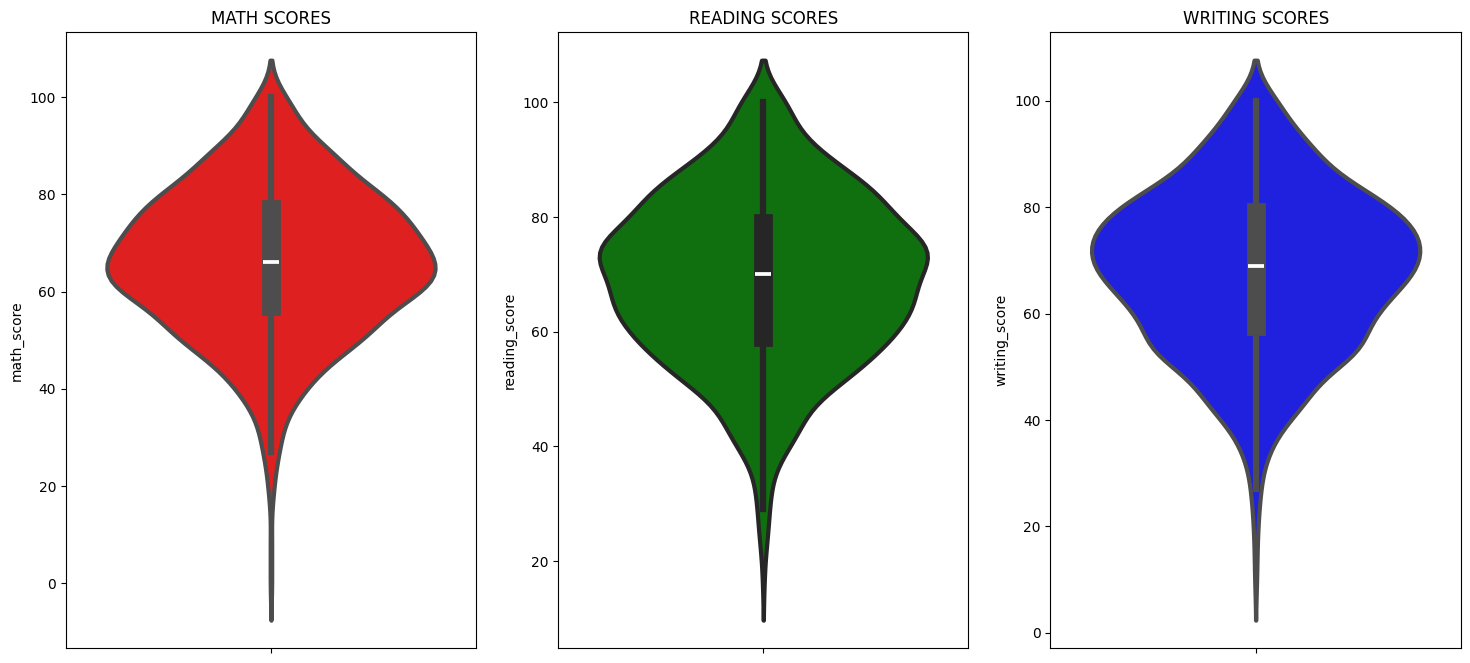

In [28]:
plt.figure(figsize=(18,8))
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

- Students performed better in Reading and Writing than in Math.
- Score distributions are fairly smooth → no extreme irregularities.
- Most students scored in the 60–80 range across all subjects.
- Reading and Writing have slightly higher central tendency (median) than Math.

# 4.3 Multivariate analysis using pieplot

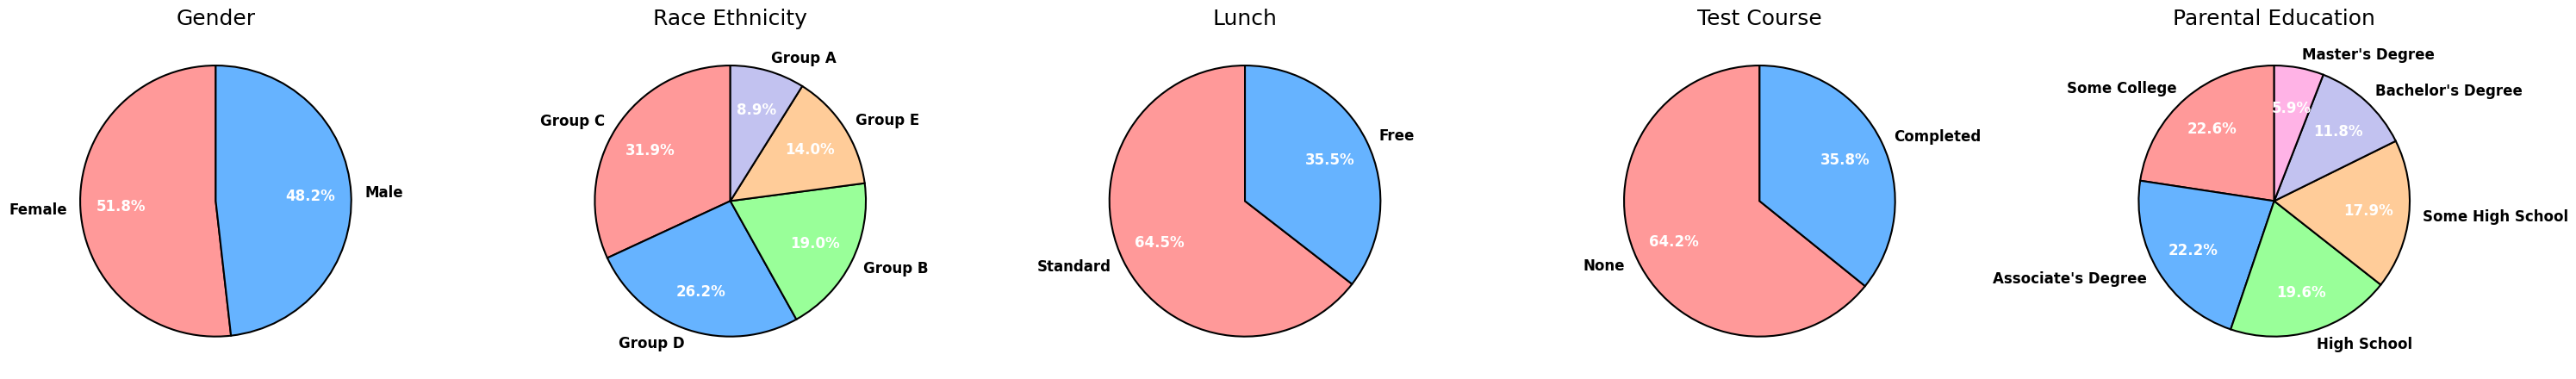

In [31]:
plt.rcParams['figure.figsize'] = (30, 12)

# Common style
textprops = {'fontsize': 12, 'weight': 'bold'}
wedgeprops = {'edgecolor': 'black', 'linewidth': 1.5}

# ---------------- Gender ----------------
plt.subplot(1, 5, 1)

size = df['gender'].value_counts()
labels = ['Female', 'Male']
colors = ['#ff9999', '#66b3ff']

wedges, texts, autotexts = plt.pie(
    size,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    textprops=textprops,
    wedgeprops=wedgeprops
)

# Make percentage text white
for autotext in autotexts:
    autotext.set_color('white')

plt.title('Gender', fontsize=18)

# ---------------- Race Ethnicity ----------------
plt.subplot(1, 5, 2)

size = df['race_ethnicity'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

wedges, texts, autotexts = plt.pie(
    size,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    textprops=textprops,
    wedgeprops=wedgeprops
)

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Race Ethnicity', fontsize=18)

# ---------------- Lunch ----------------
plt.subplot(1, 5, 3)

size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
colors = ['#ff9999', '#66b3ff']

wedges, texts, autotexts = plt.pie(
    size,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    textprops=textprops,
    wedgeprops=wedgeprops
)

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Lunch', fontsize=18)

# ---------------- Test Course ----------------
plt.subplot(1, 5, 4)

size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
colors = ['#ff9999', '#66b3ff']

wedges, texts, autotexts = plt.pie(
    size,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    textprops=textprops,
    wedgeprops=wedgeprops
)

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Test Course', fontsize=18)

# ---------------- Parental Education ----------------
plt.subplot(1, 5, 5)

size = df['parental_level_of_education'].value_counts()

labels = [
    'Some College',
    "Associate's Degree",
    'High School',
    'Some High School',
    "Bachelor's Degree",
    "Master's Degree"
]

colors = ['#ff9999', '#66b3ff', '#99ff99',
          '#ffcc99', '#c2c2f0', '#ffb3e6']

wedges, texts, autotexts = plt.pie(
    size,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    textprops=textprops,
    wedgeprops=wedgeprops
)

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Parental Education', fontsize=18)

plt.tight_layout()
plt.show()

Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

# 4.4 Feature Wise Visualization

4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

<h4>UNIVARIATE ANALYSIS ( How is distribution of Gender ? )</h4>

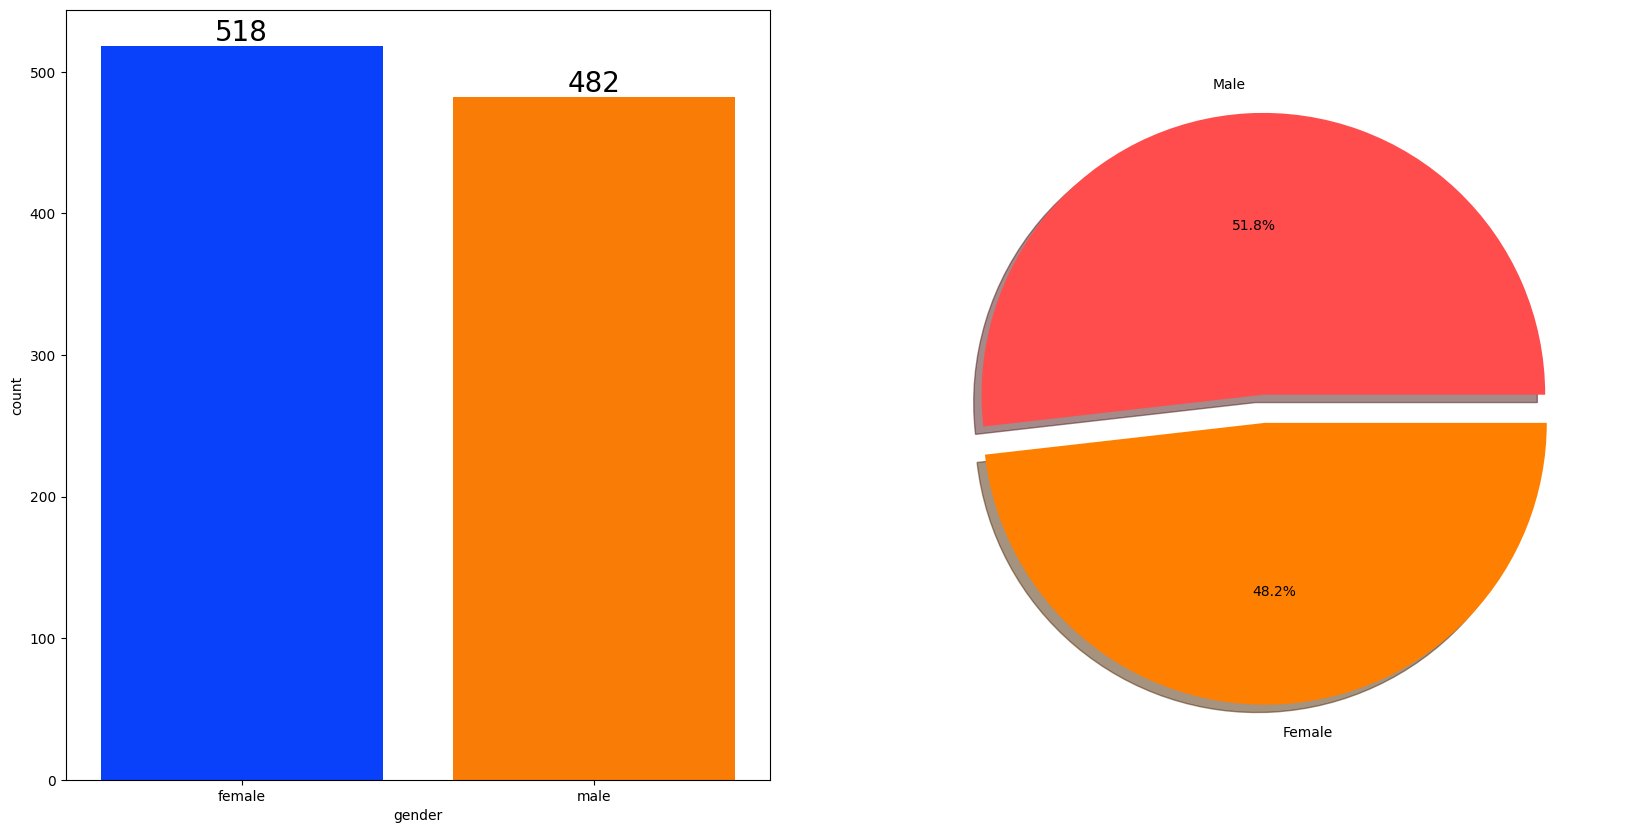

In [32]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

Insights

- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

<h4>BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )</h4>

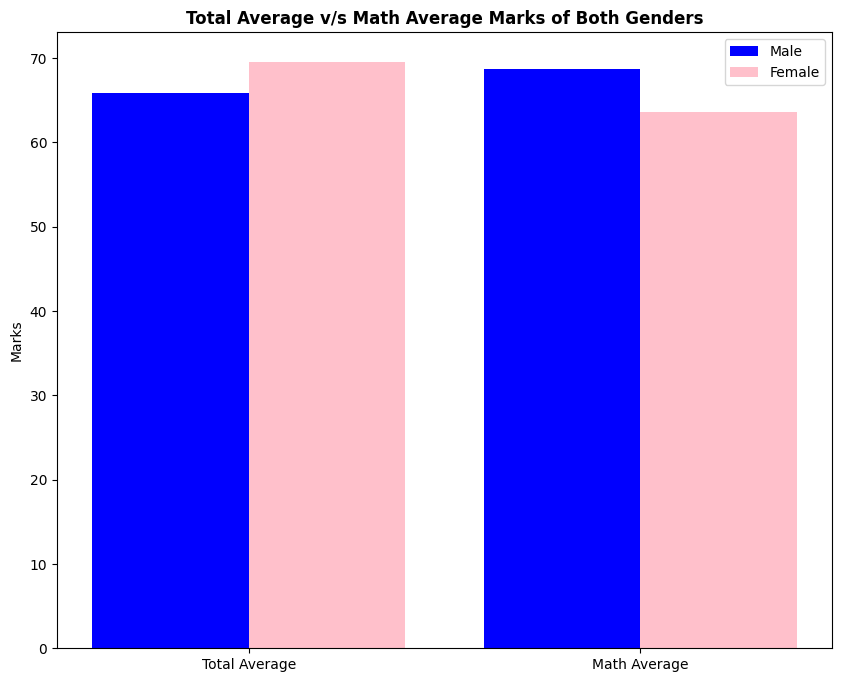

In [39]:
# Group by gender and calculate mean only for numeric columns
gender_group = df.groupby('gender').mean(numeric_only=True)

plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

# Get values properly using loc
female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

# Bar plots
plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male', color='blue')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female', color='pink')

# Labels and title
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title(
    "Total Average v/s Math Average Marks of Both Genders",
    fontweight='bold'
)

plt.legend()
plt.show()

Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

4.4.2 RACE/EHNICITY COLUMN

- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

<h4>UNIVARIATE ANALYSIS ( How is Group wise distribution ?)</h4>

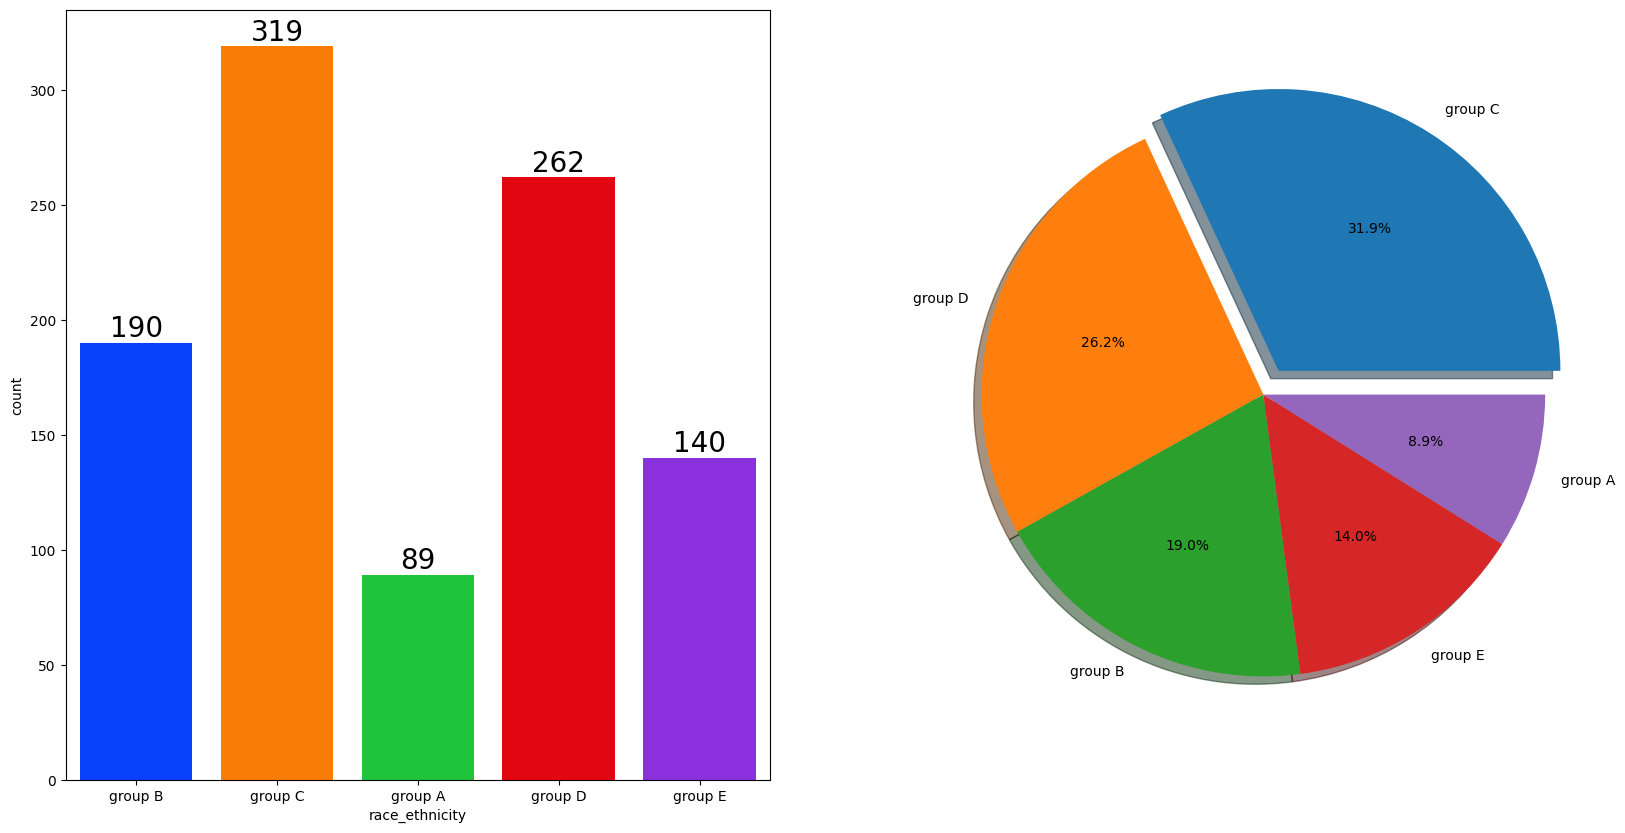

In [40]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

<h4>BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )</h4>

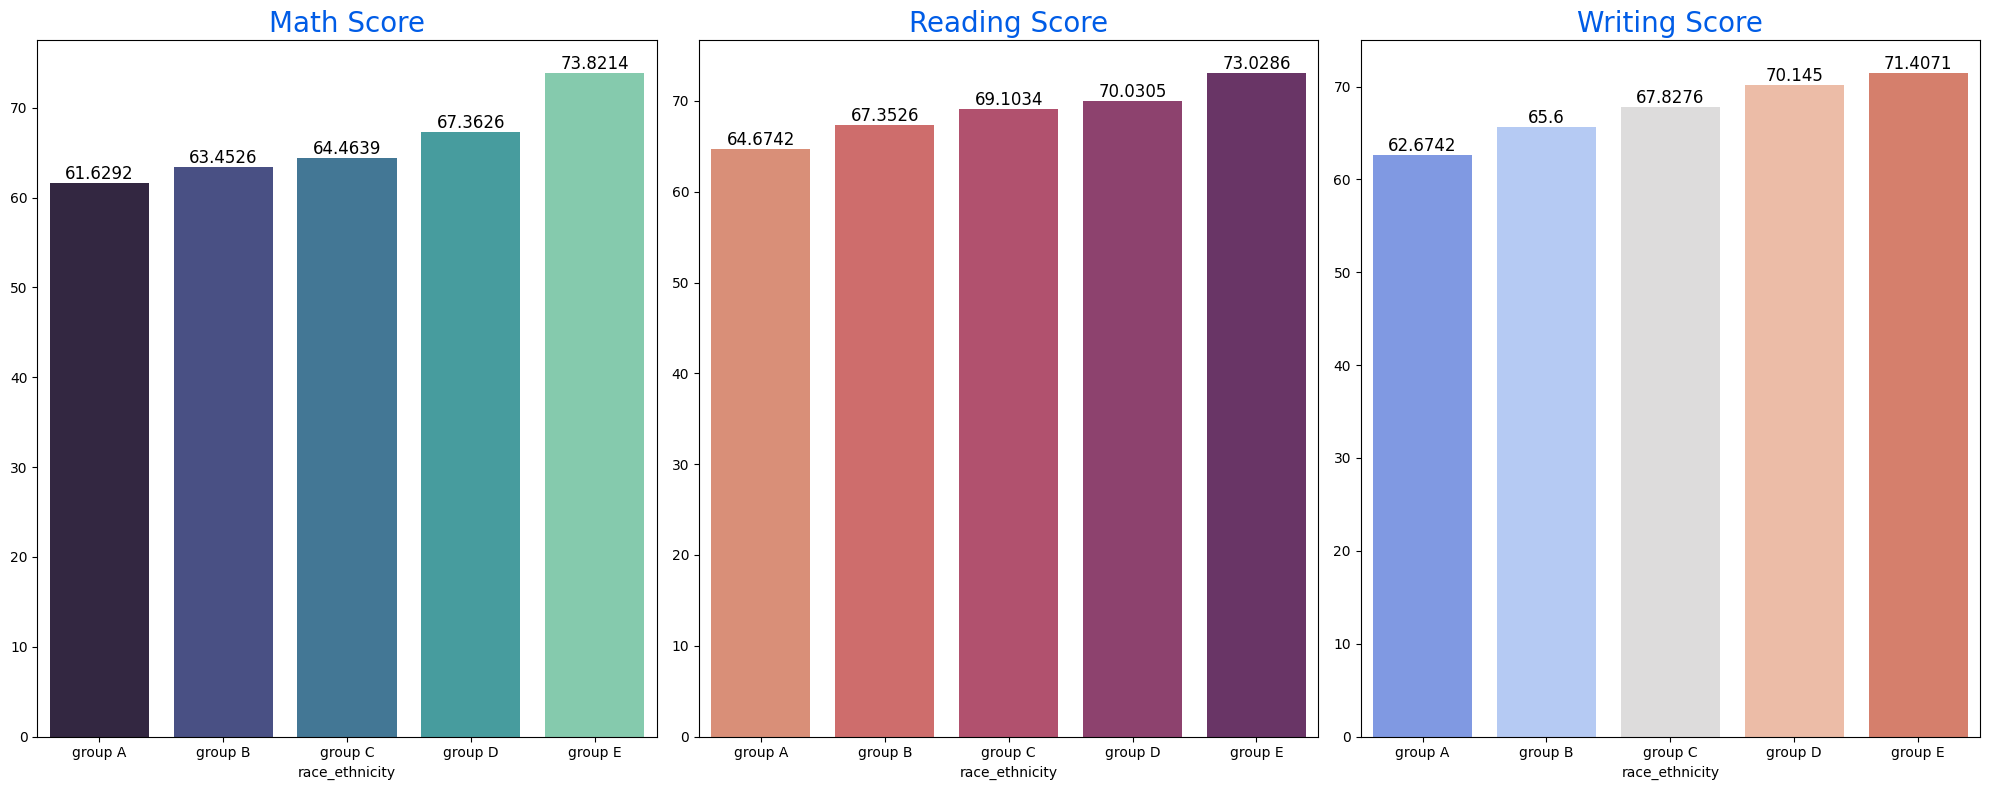

In [43]:
# Grouping
Group_data2 = df.groupby('race_ethnicity')

# Figure
f, ax = plt.subplots(1, 3, figsize=(20, 8))

# ---------------- Math Score ----------------
sns.barplot(
    x=Group_data2['math_score'].mean().index,
    y=Group_data2['math_score'].mean().values,
    hue=Group_data2['math_score'].mean().index,   # Added for newer seaborn
    palette='mako',
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Math Score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)

# ---------------- Reading Score ----------------
sns.barplot(
    x=Group_data2['reading_score'].mean().index,
    y=Group_data2['reading_score'].mean().values,
    hue=Group_data2['reading_score'].mean().index,
    palette='flare',
    legend=False,
    ax=ax[1]
)

ax[1].set_title('Reading Score', color='#005ce6', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12)

# ---------------- Writing Score ----------------
sns.barplot(
    x=Group_data2['writing_score'].mean().index,
    y=Group_data2['writing_score'].mean().values,
    hue=Group_data2['writing_score'].mean().index,
    palette='coolwarm',
    legend=False,
    ax=ax[2]
)

ax[2].set_title('Writing Score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=12)

plt.tight_layout()
plt.show()

Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

<h4>UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )</h4>

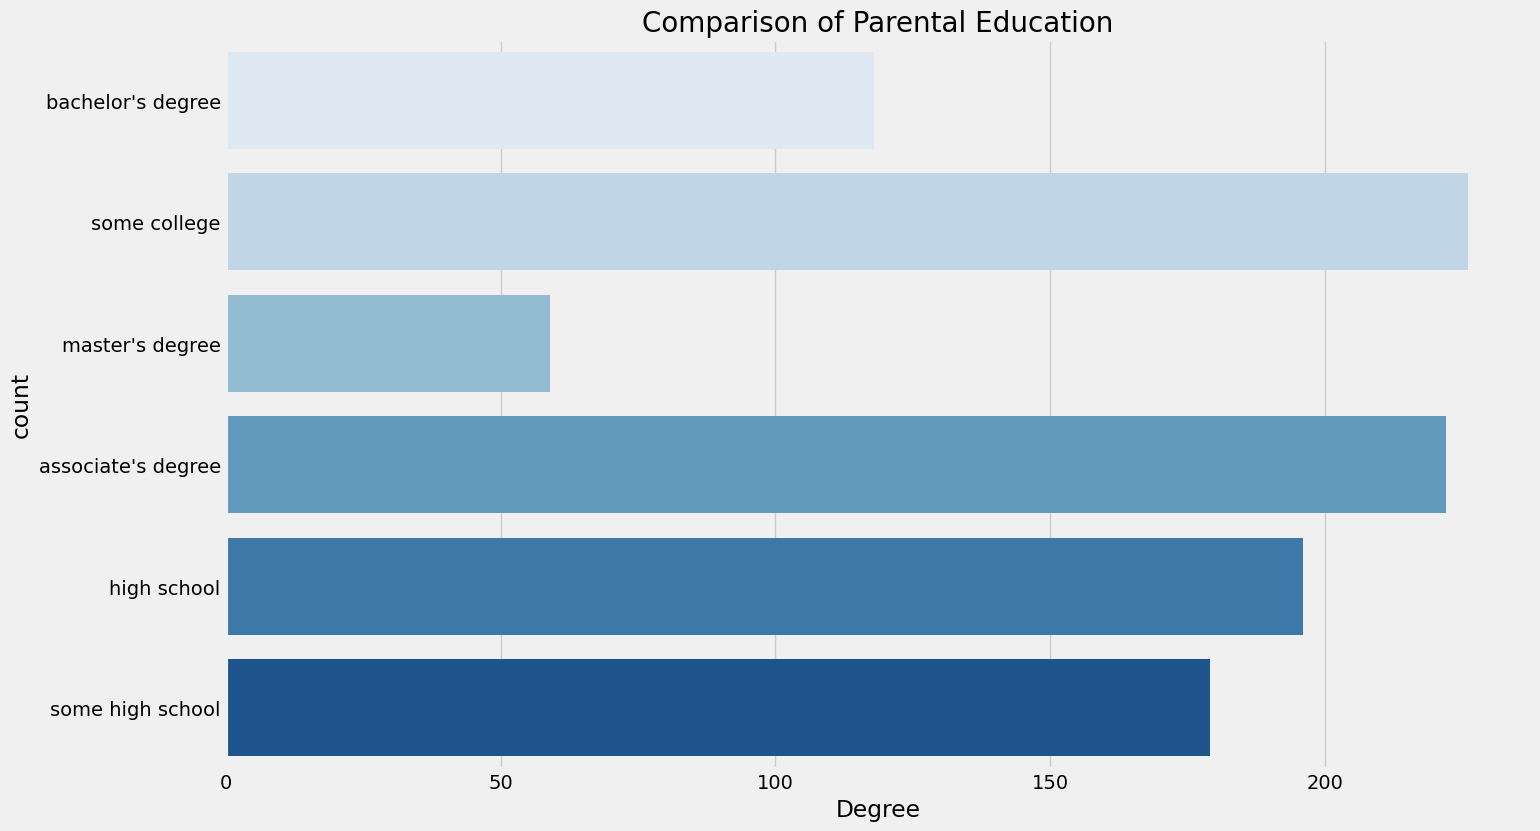

In [45]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

Insights
- Largest number of parents are from some college.

<h4>BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )</h4>

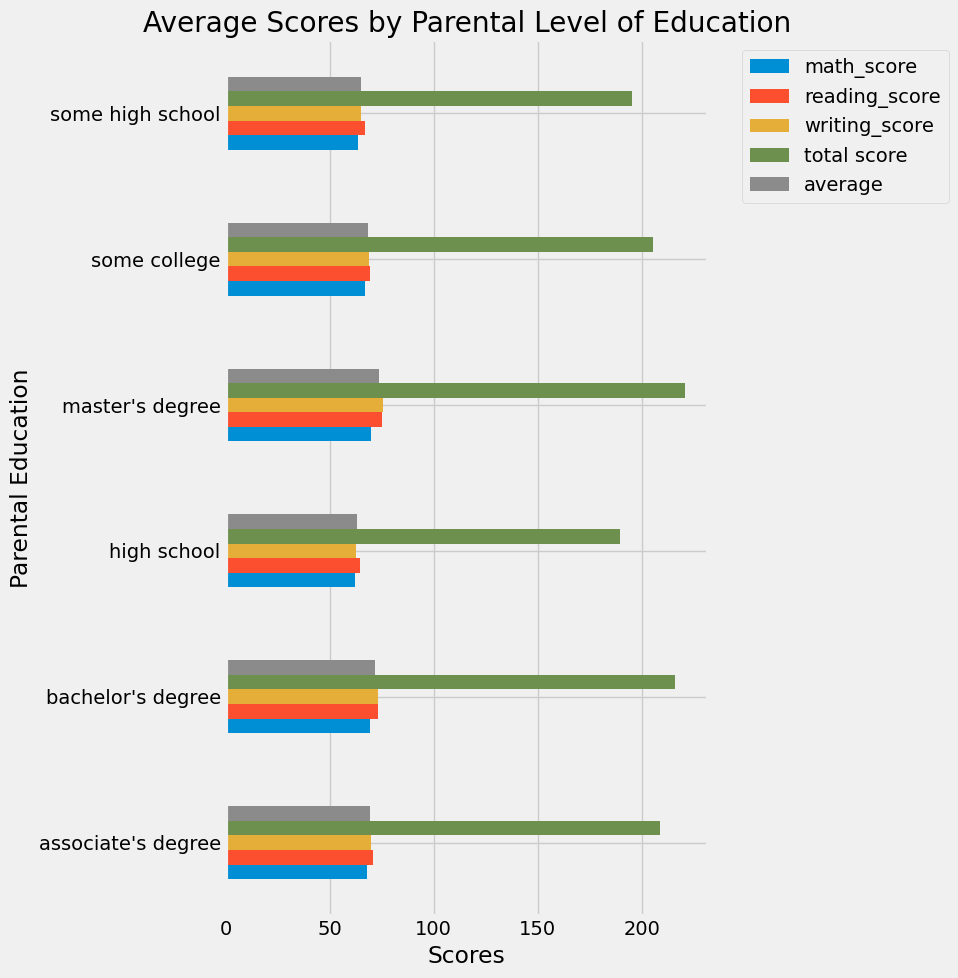

In [47]:
# Group by parental education and calculate mean of numeric columns only
group_data = df.groupby(
    'parental_level_of_education'
).mean(numeric_only=True)

# Plot
group_data.plot(
    kind='barh',
    figsize=(10, 10)
)

# Legend outside graph
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('Average Scores by Parental Level of Education')
plt.xlabel('Scores')
plt.ylabel('Parental Education')

plt.tight_layout()
plt.show()

Insights
- The score of student whose parents possess master and bachelor level education are higher than others

# 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?

<h4>UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )</h4>

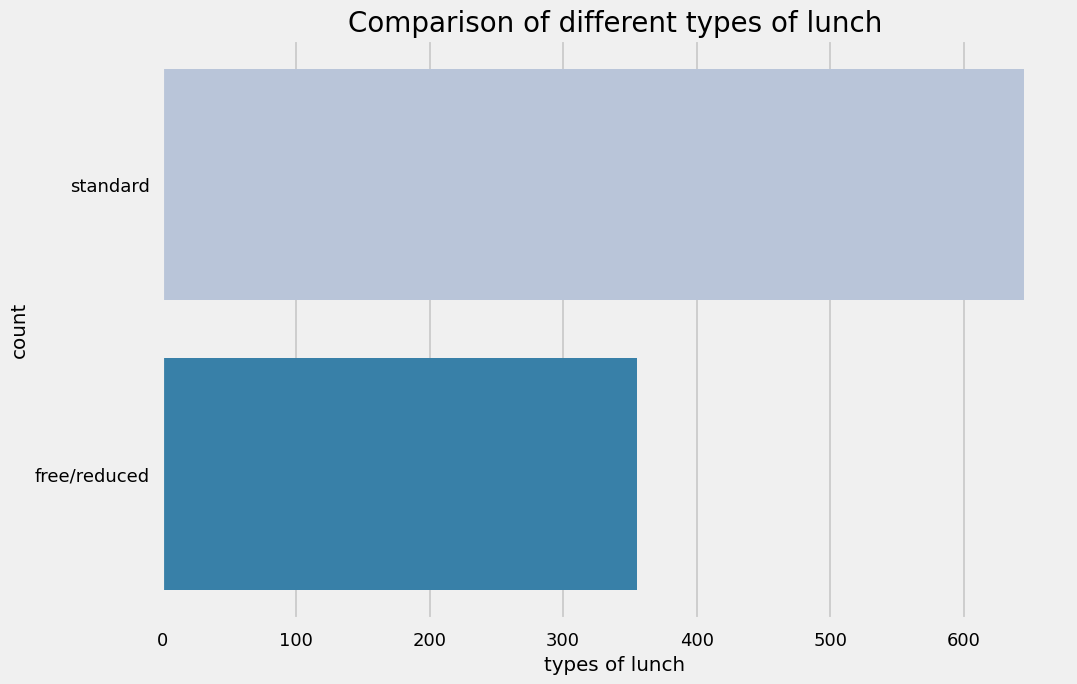

In [50]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()


Insights
- Students being served Standard lunch was more than free lunch